In [3]:
import pandas as pd



## Exploration of the dataset

In [4]:
# Load the dataset 
df = pd.read_csv('cms_Hbb.csv')

# Display basic information
print(f"Number of records: {df.shape[0]}")
print(f"Number of features: {df.shape[1]}")
print("\nFirst 5 rows of the dataset:")
print(df.head())

#check data types and missing values
print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())

Number of records: 225868
Number of features: 29

First 5 rows of the dataset:
   Unnamed: 0  jetNTracks  nSV  tau0_trackEtaRel_0  tau0_trackEtaRel_1  \
0          43        16.0  3.0            3.317515            3.639308   
1          49        15.0  2.0            2.253551            2.388026   
2          59        21.0  1.0            2.187342            2.213301   
3          77        41.0  4.0            1.001850            1.031202   
4          83        20.0  3.0            1.892475            1.999694   

   tau0_trackEtaRel_2  tau1_trackEtaRel_0  tau1_trackEtaRel_1  \
0            4.303862            4.190607            4.428059   
1            4.131536            1.834991            4.299034   
2            3.812317            1.103252            1.177770   
3            1.032491            3.086385            4.062065   
4            4.548122            1.874205            2.477724   

   tau1_trackEtaRel_2  tau_flightDistance2dSig_0  ...  trackSipdSig_0  \
0           

In [5]:
suspicious_values = [-999, 999, -1, 0]

for value in suspicious_values:
    print(f"Value {value}:")
    print((df == value).sum(), "\n")


Value -999:
Unnamed: 0                    0
jetNTracks                    0
nSV                           0
tau0_trackEtaRel_0            0
tau0_trackEtaRel_1            0
tau0_trackEtaRel_2            0
tau1_trackEtaRel_0            0
tau1_trackEtaRel_1            0
tau1_trackEtaRel_2            0
tau_flightDistance2dSig_0     0
tau_flightDistance2dSig_1     0
tau_vertexDeltaR_0            0
tau_vertexEnergyRatio_0       0
tau_vertexEnergyRatio_1       0
tau_vertexMass_0              0
tau_vertexMass_1              0
trackSip2dSigAboveBottom_0    0
trackSip2dSigAboveBottom_1    0
trackSip2dSigAboveCharm_0     0
trackSipdSig_0                0
trackSipdSig_0_0              0
trackSipdSig_0_1              0
trackSipdSig_1                0
trackSipdSig_1_0              0
trackSipdSig_1_1              0
trackSipdSig_2                0
trackSipdSig_3                0
isBackground                  0
isSignal                      0
dtype: int64 

Value 999:
Unnamed: 0                    1
je

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def plot_histogram_by_label(df, column, bins=50):
    sig = df[df['isSignal'] == 1][column]
    bkg = df[df['isSignal'] == 0][column]

    # Define common bin edges
    bin_edges = np.histogram_bin_edges(df[column], bins=bins)

    # Create a single figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # --- Linear Scale (Left subplot) ---
    ax1.hist(bkg, bins=bin_edges, alpha=0.5, label='Background (0)', density=True, color='red')
    ax1.hist(sig, bins=bin_edges, alpha=0.5, label='Signal (1)', density=True, color='blue')
    ax1.set_title(f'Distribution of {column} (Linear Scale)')
    ax1.set_xlabel(column)
    ax1.set_ylabel('Density')
    ax1.legend()
    ax1.grid(True)
    
    # --- Logarithmic Scale (Right subplot) ---
    ax2.hist(bkg, bins=bin_edges, alpha=0.5, label='Background (0)', density=True, color='red', log=True)
    ax2.hist(sig, bins=bin_edges, alpha=0.5, label='Signal (1)', density=True, color='blue', log=True)
    ax2.set_title(f'Distribution of {column} (Log Scale)')
    ax2.set_xlabel(column)
    ax2.set_ylabel('Log Density')
    ax2.legend()
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()

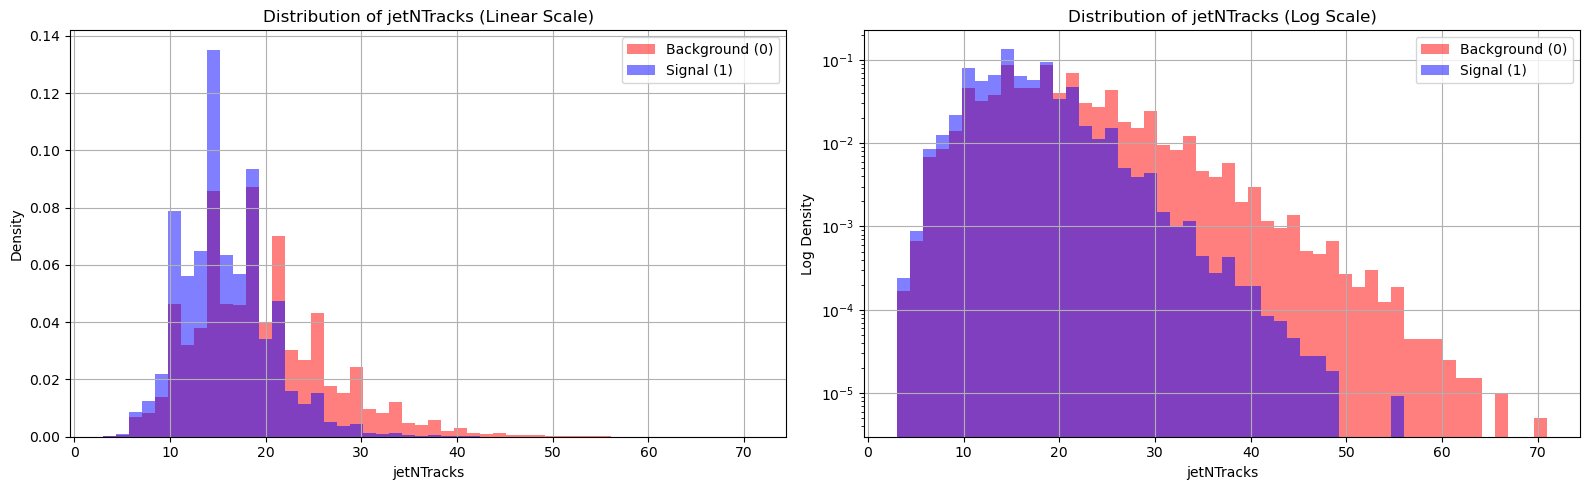

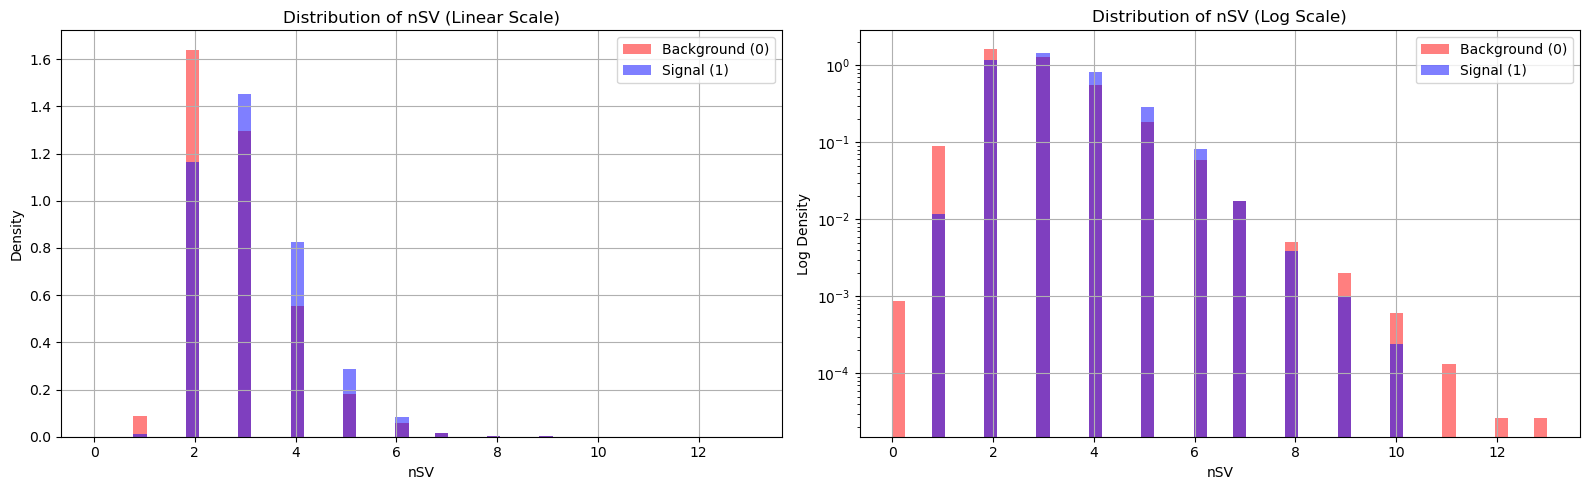

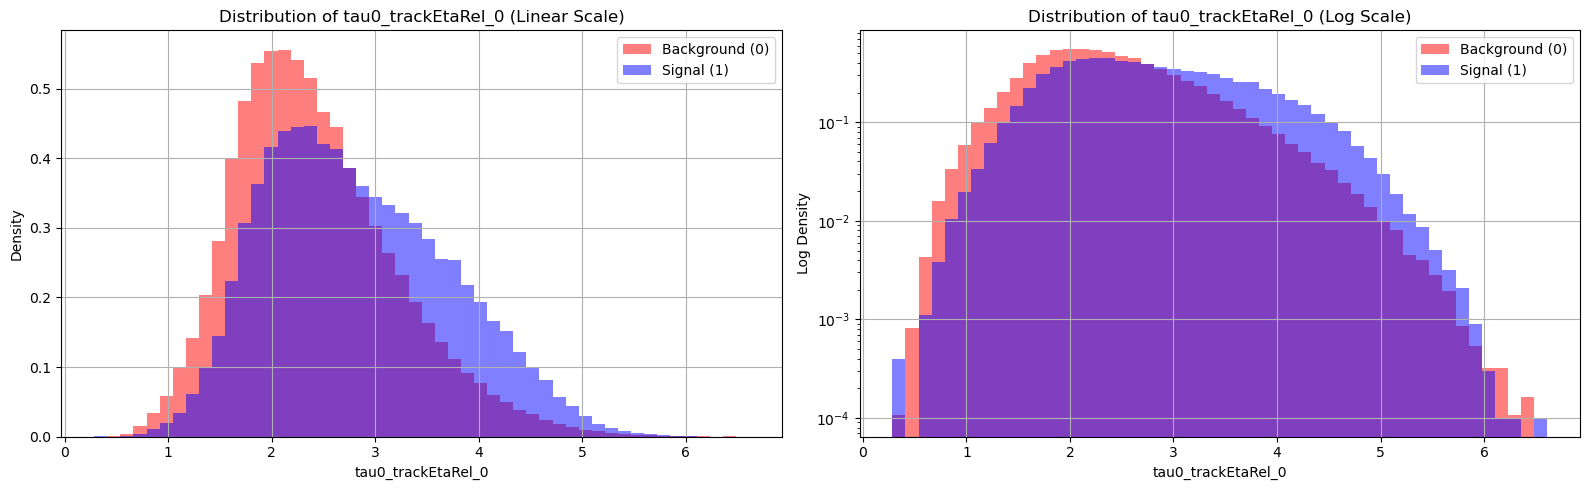

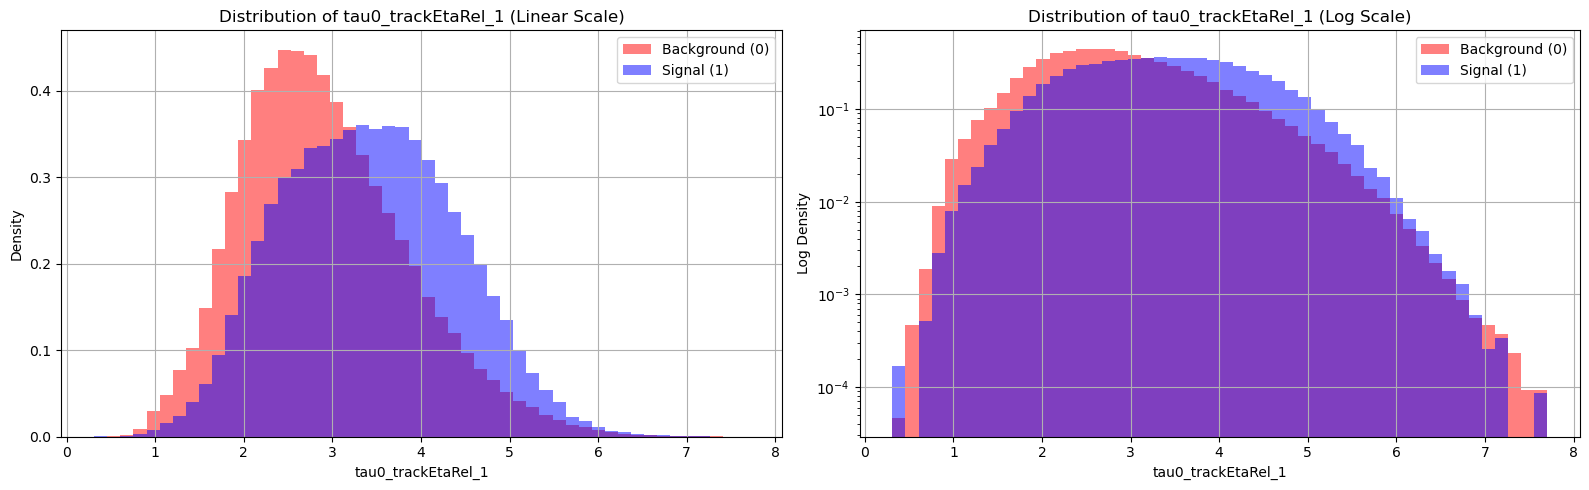

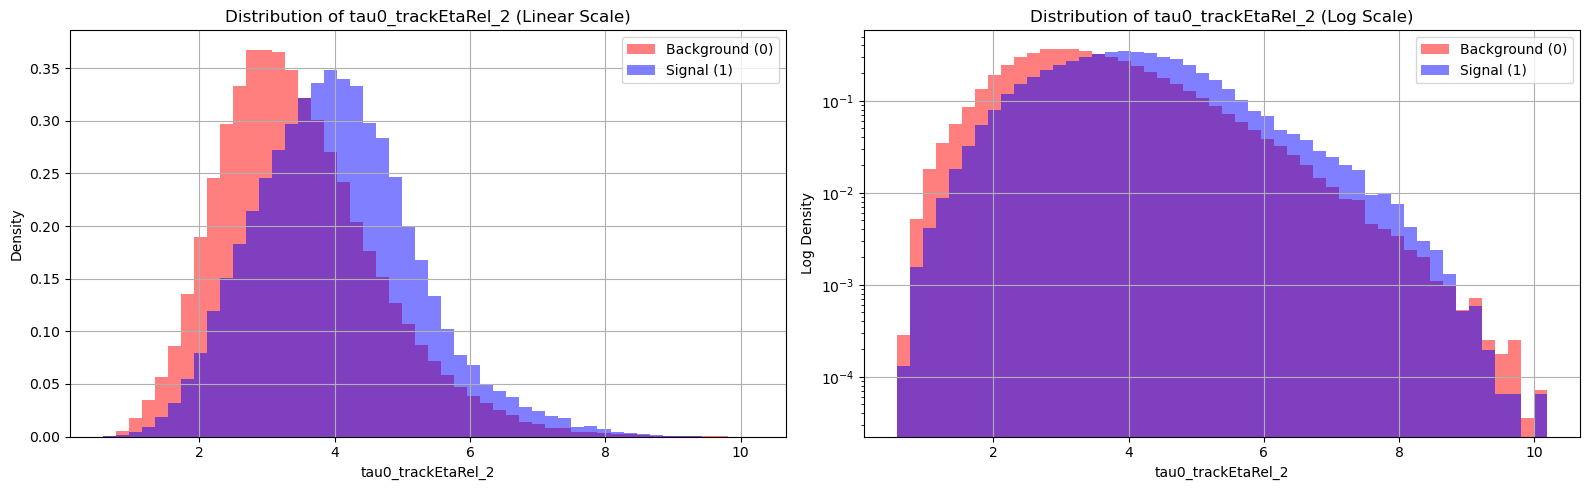

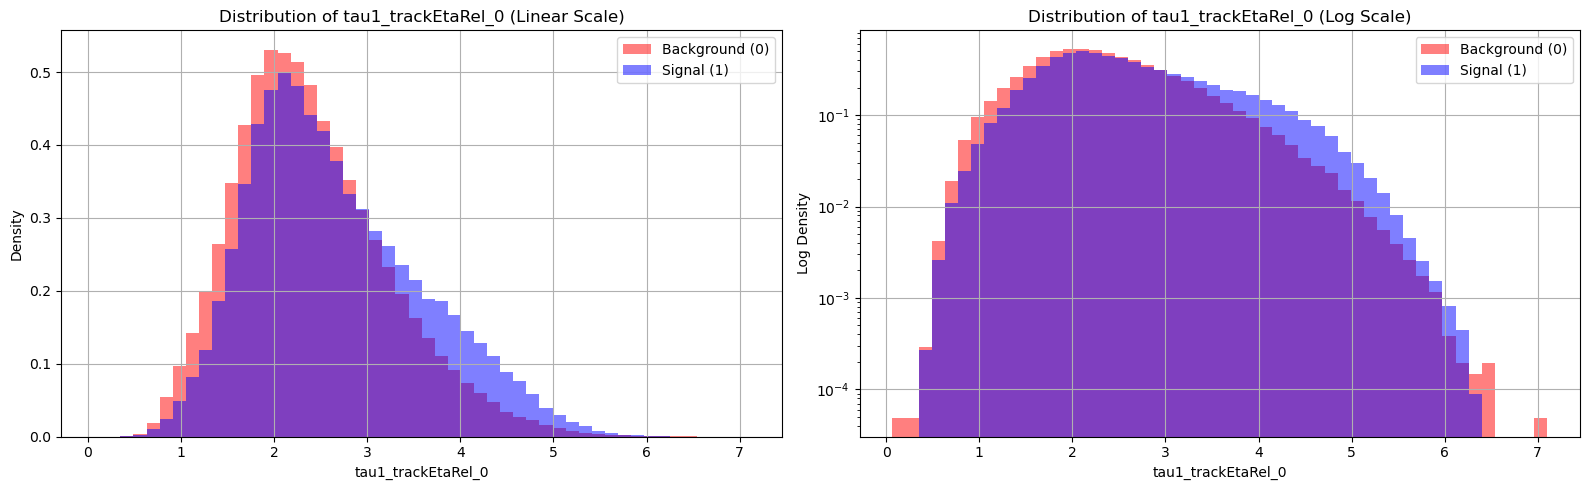

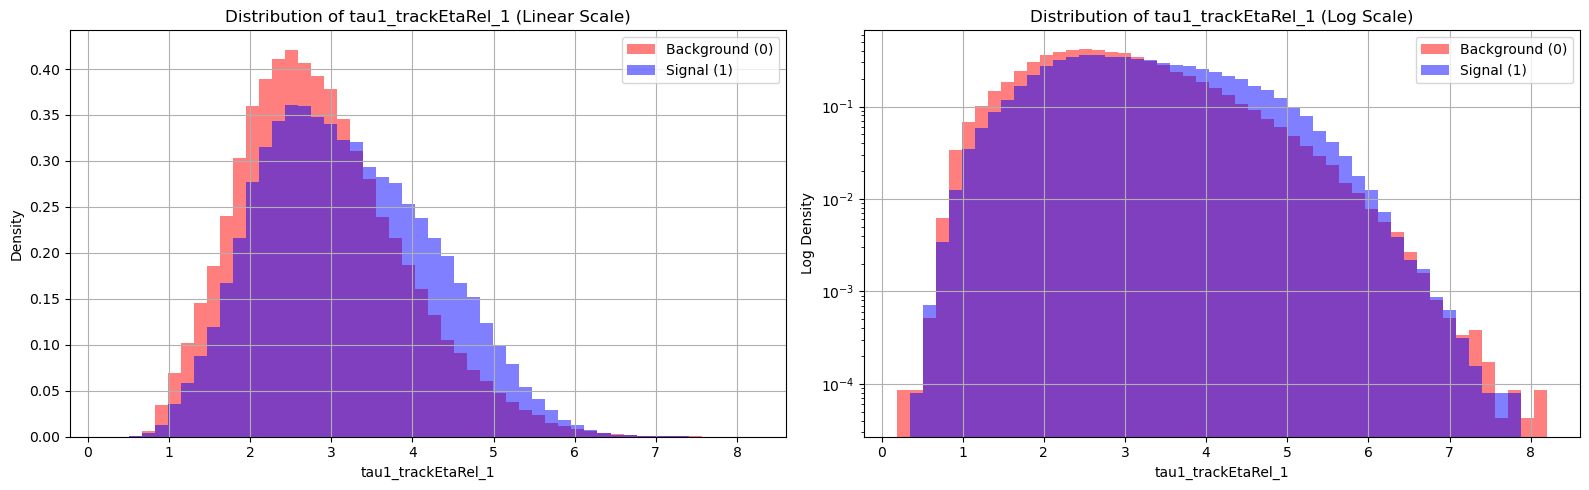

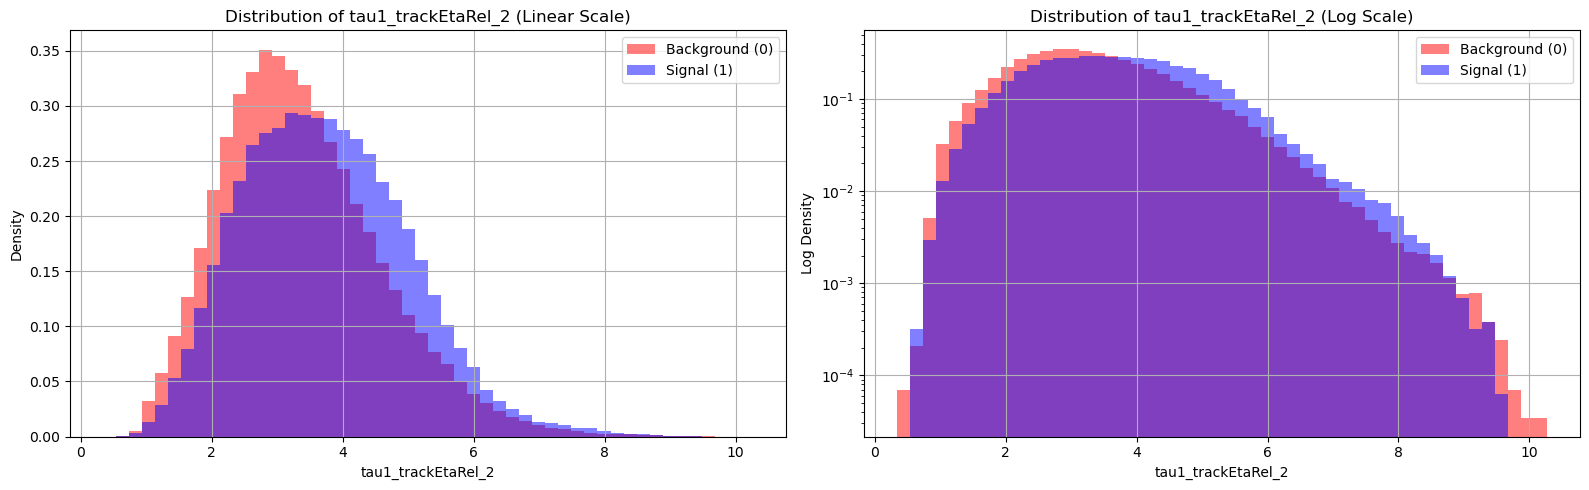

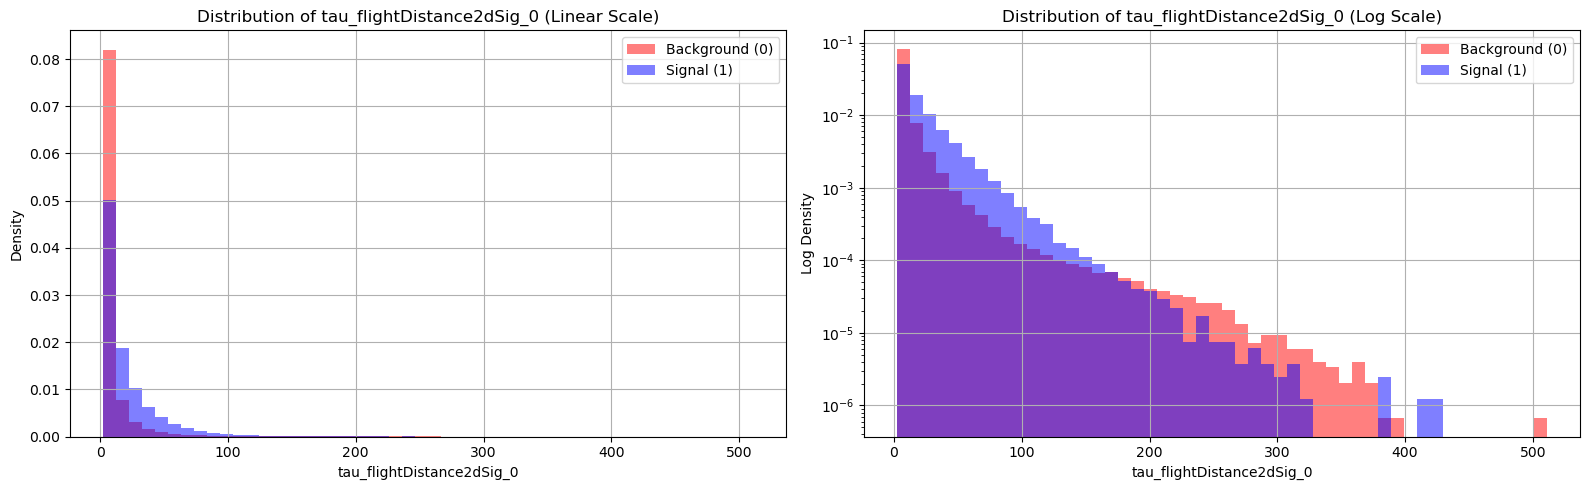

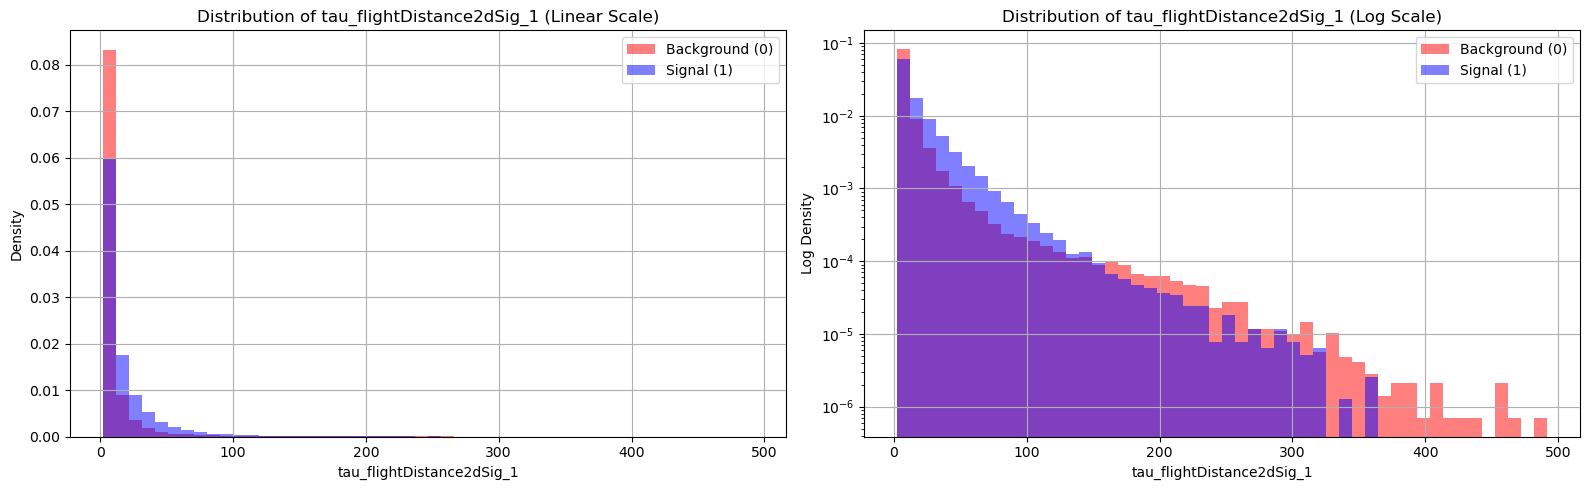

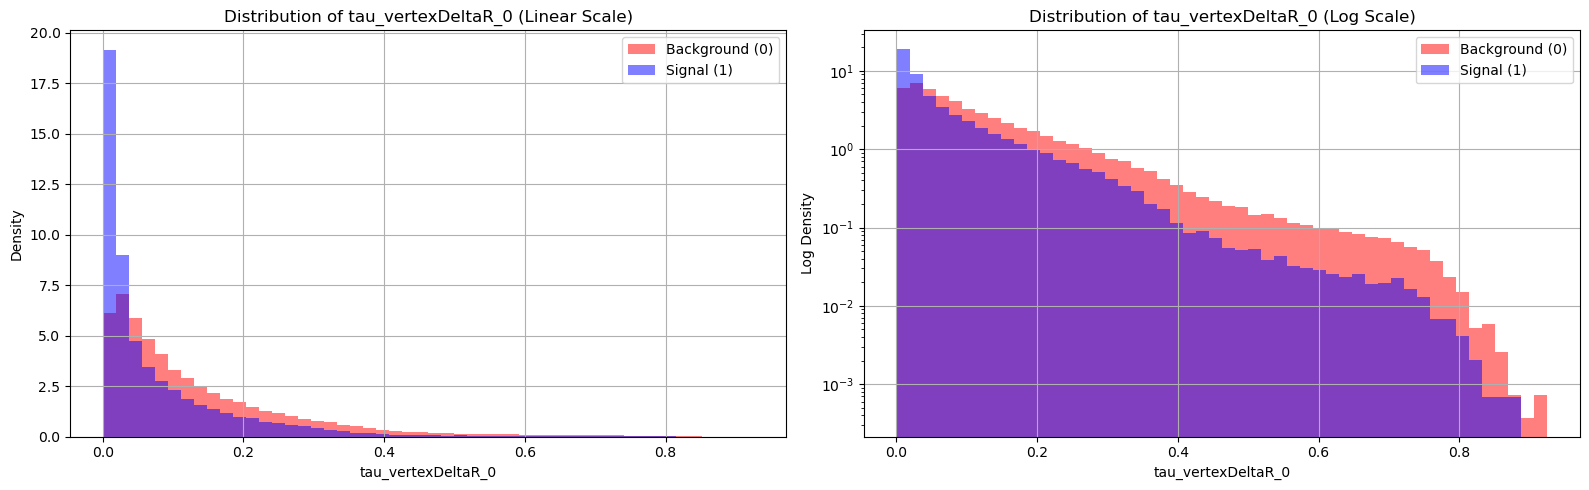

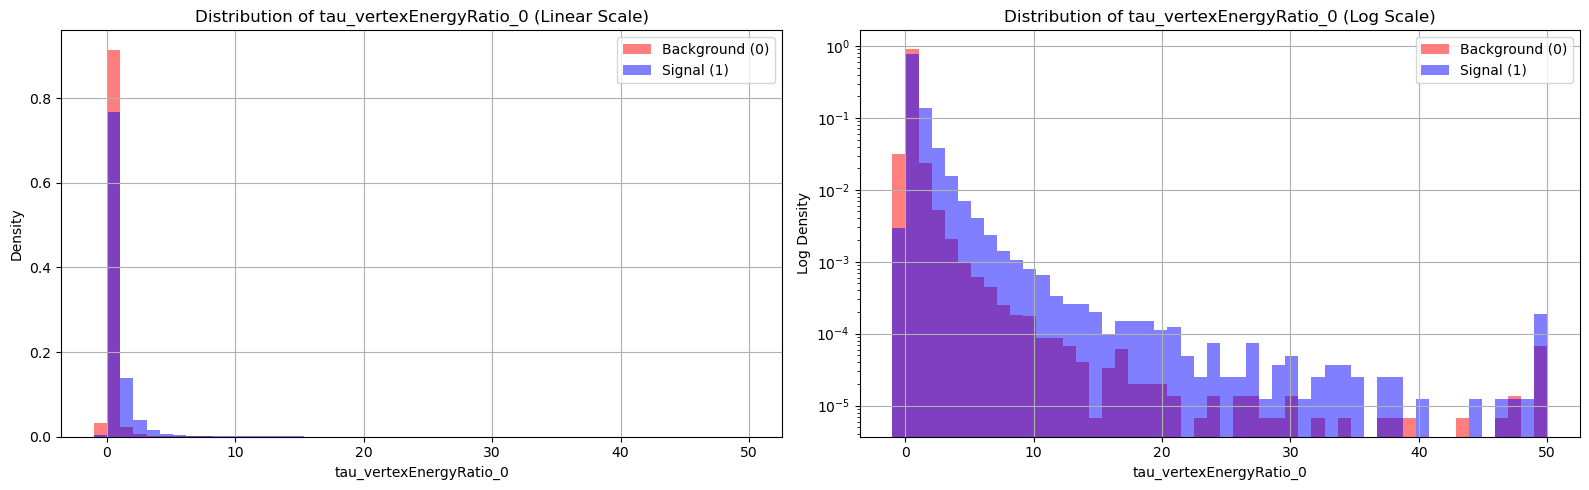

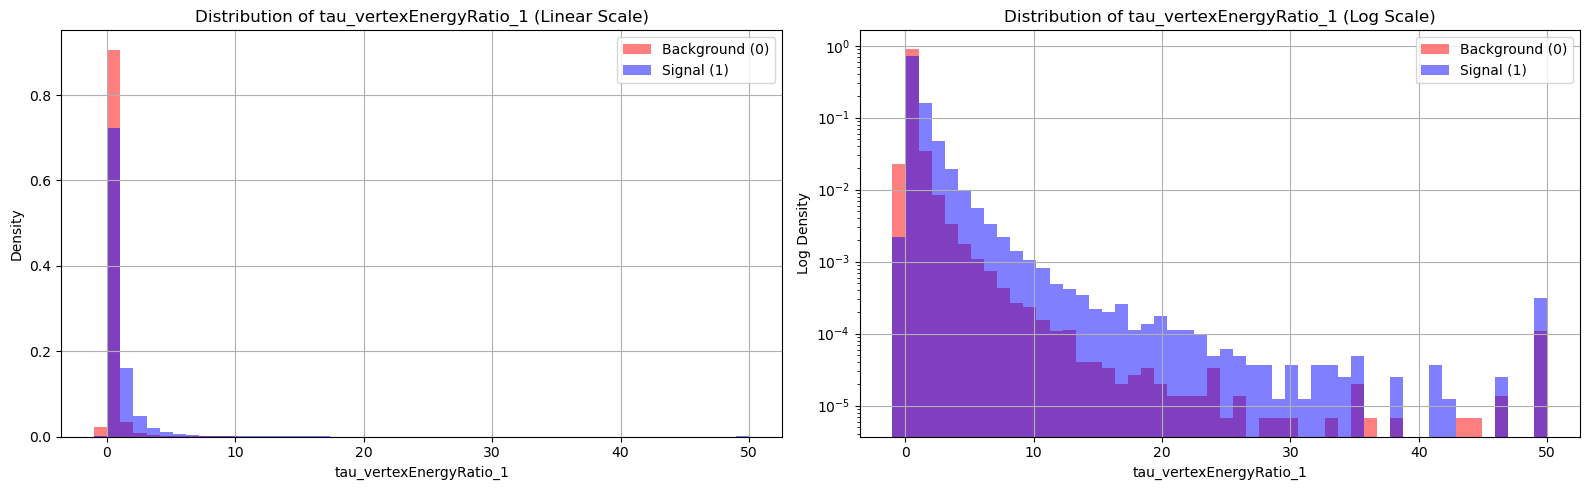

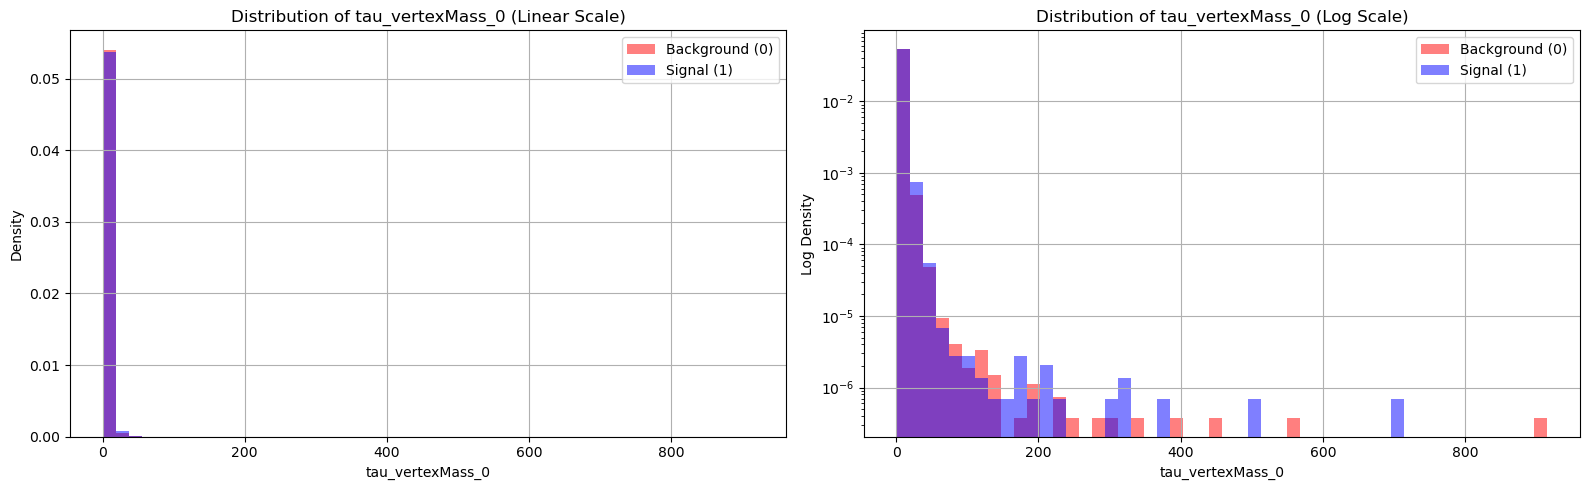

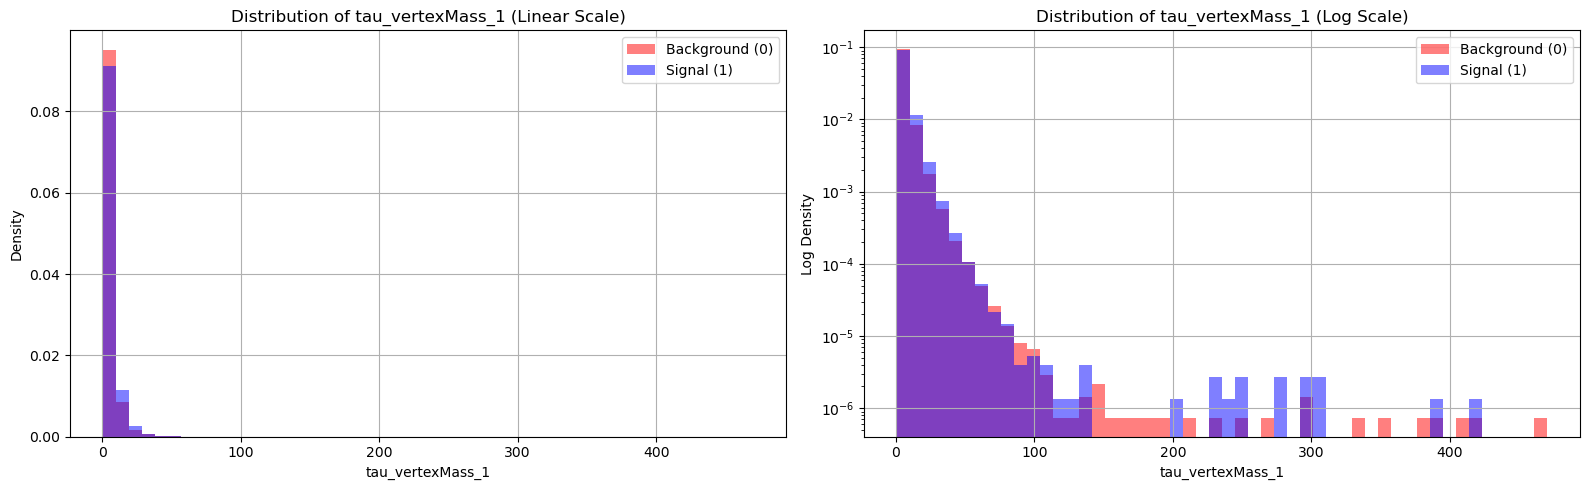

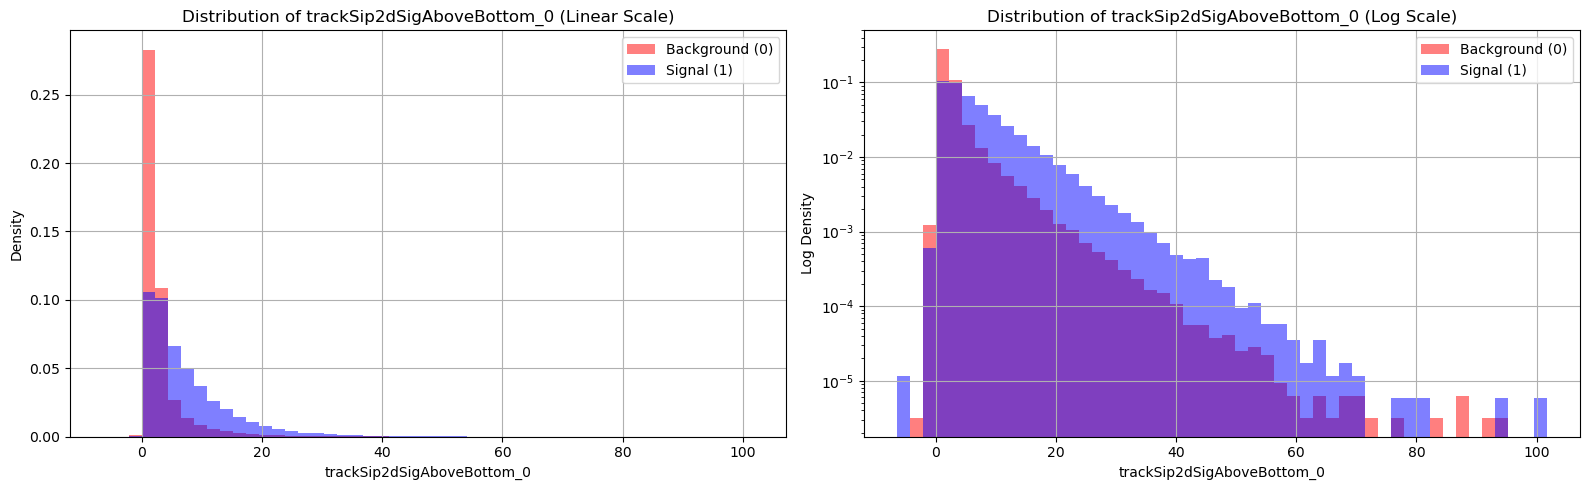

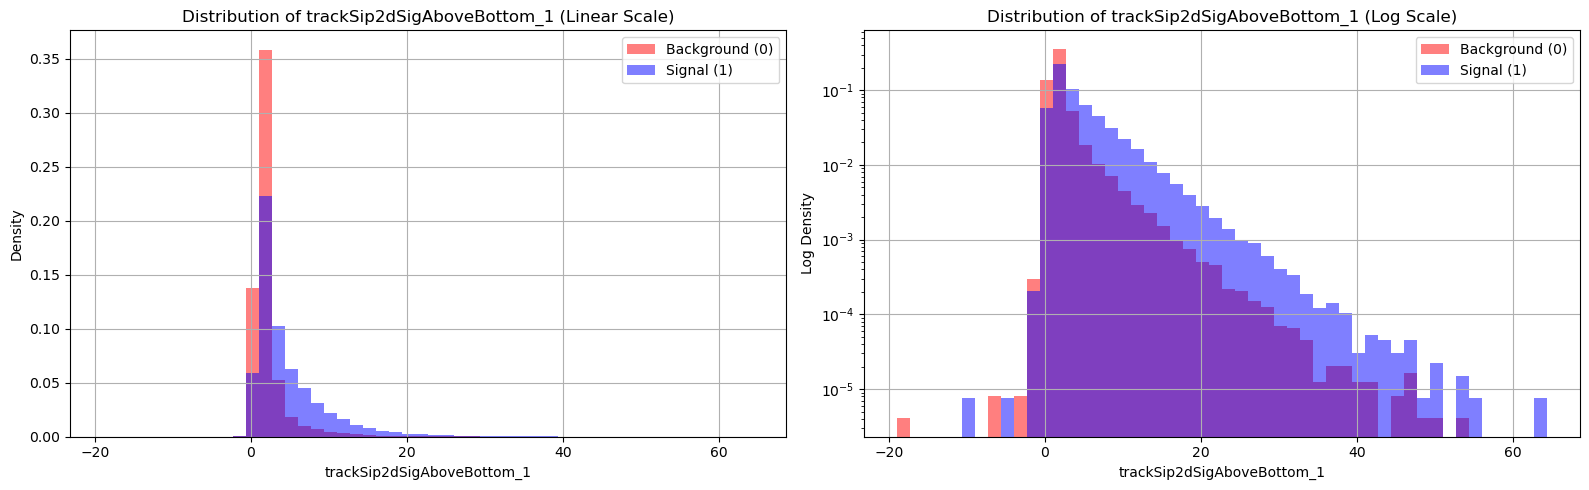

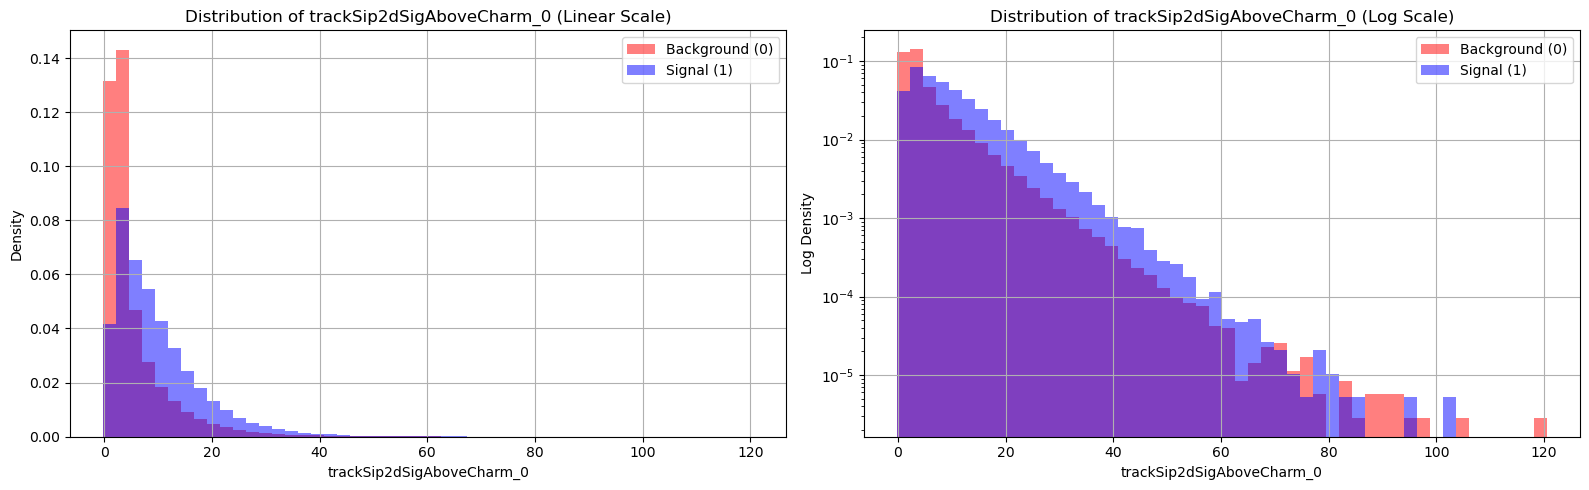

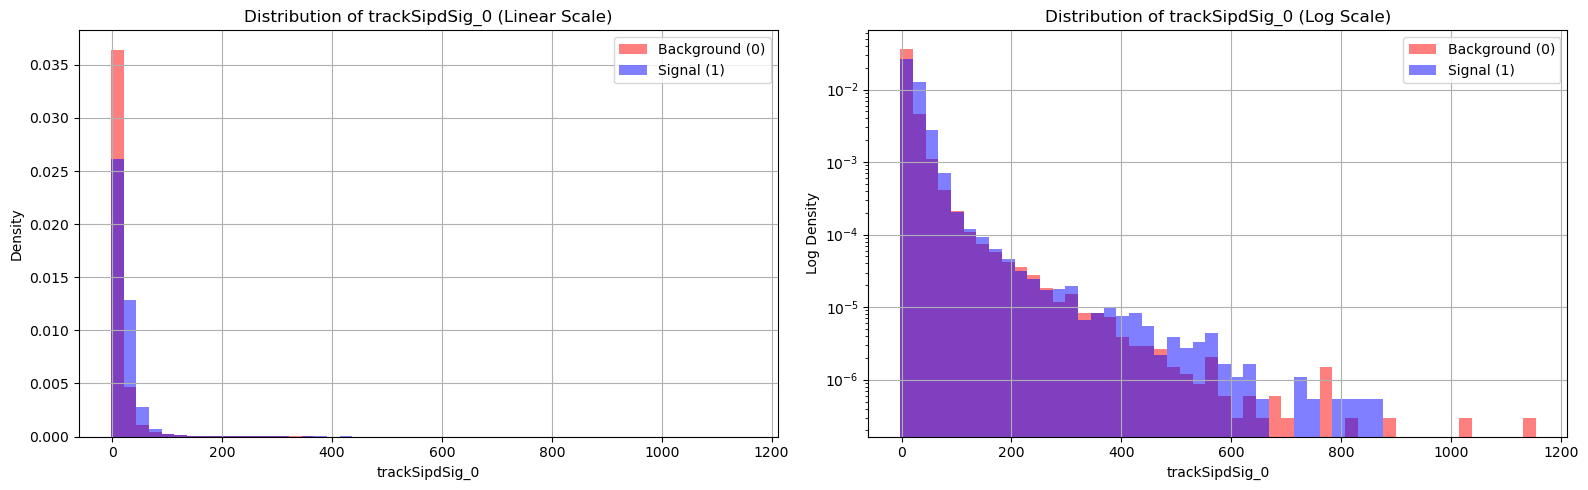

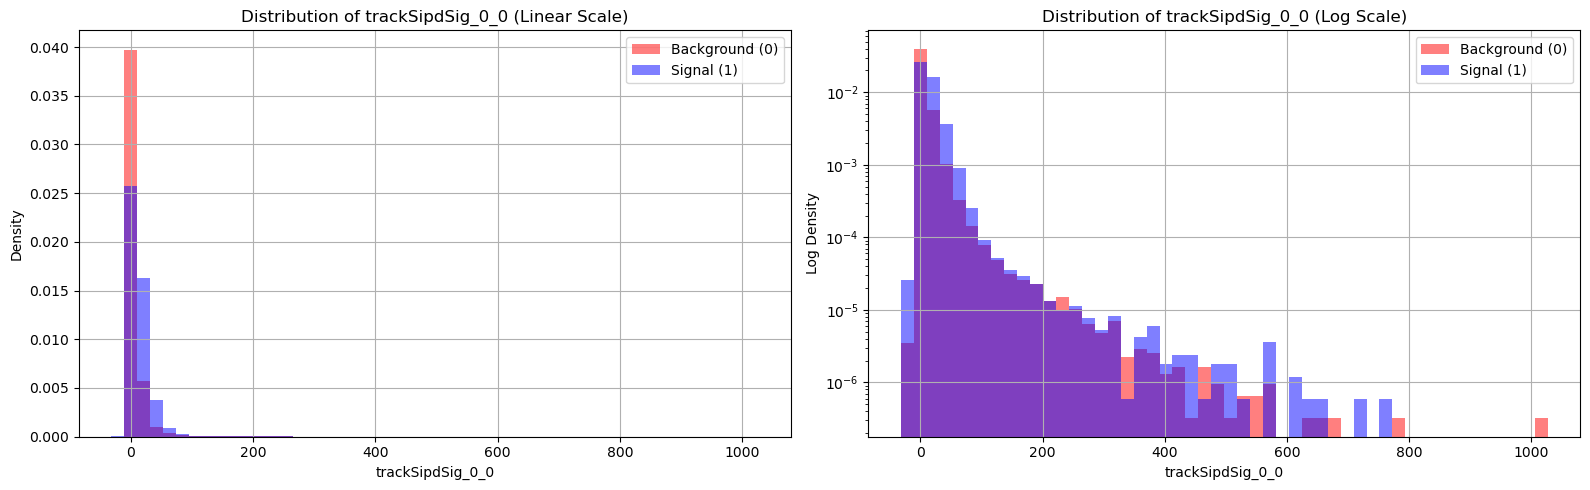

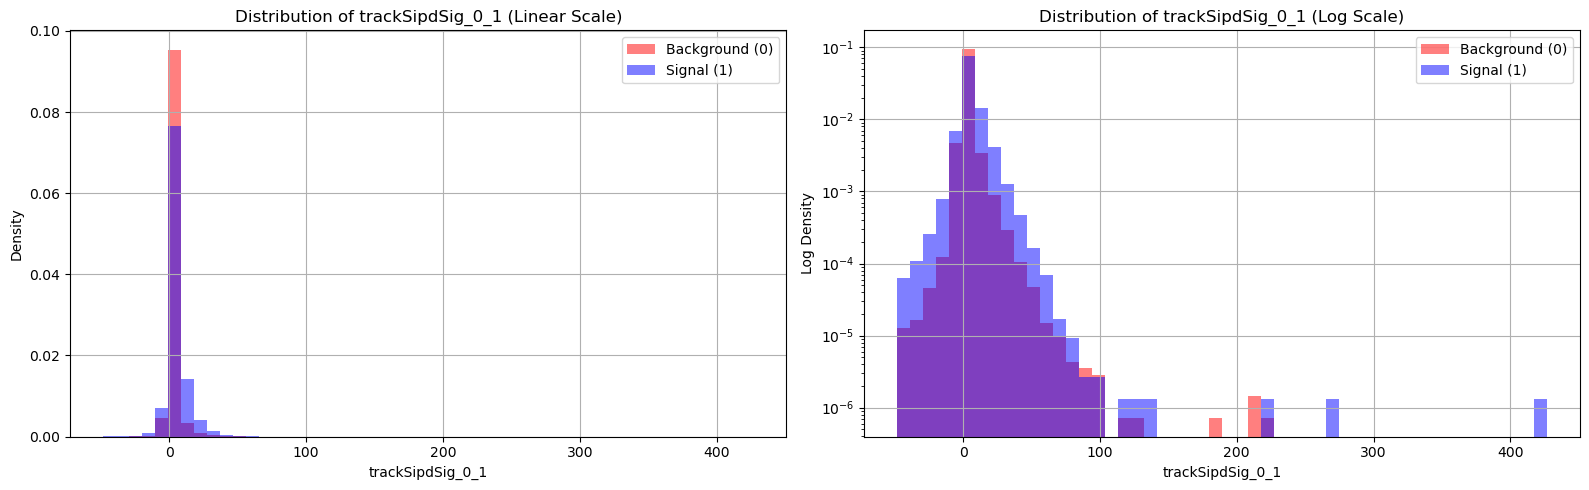

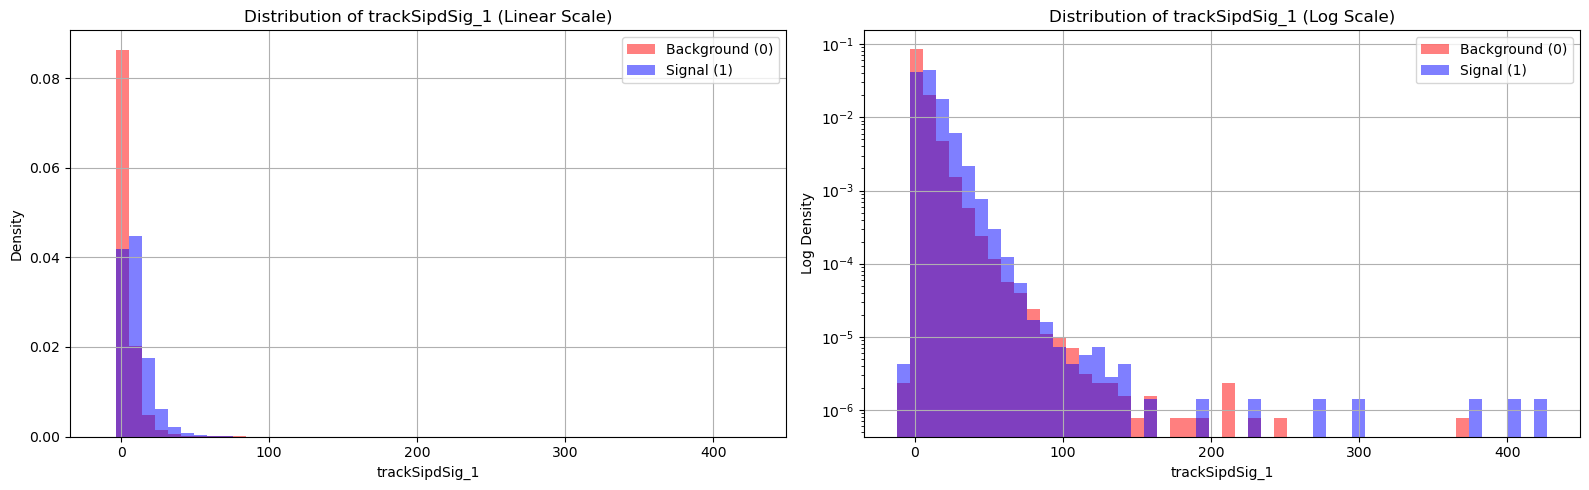

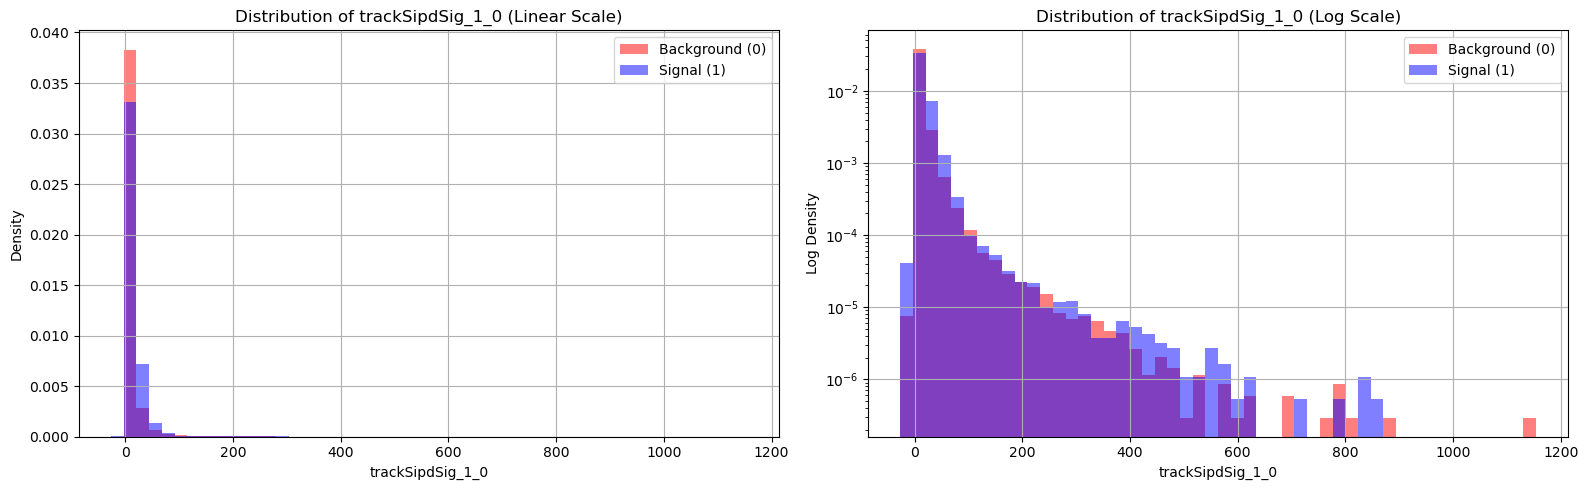

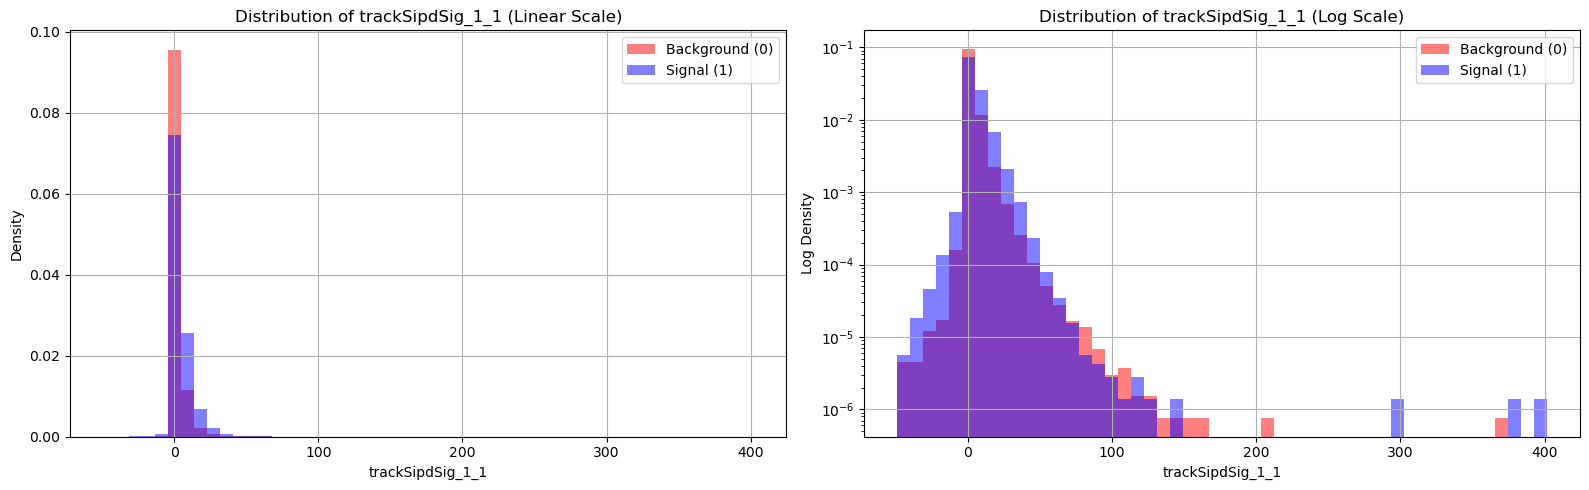

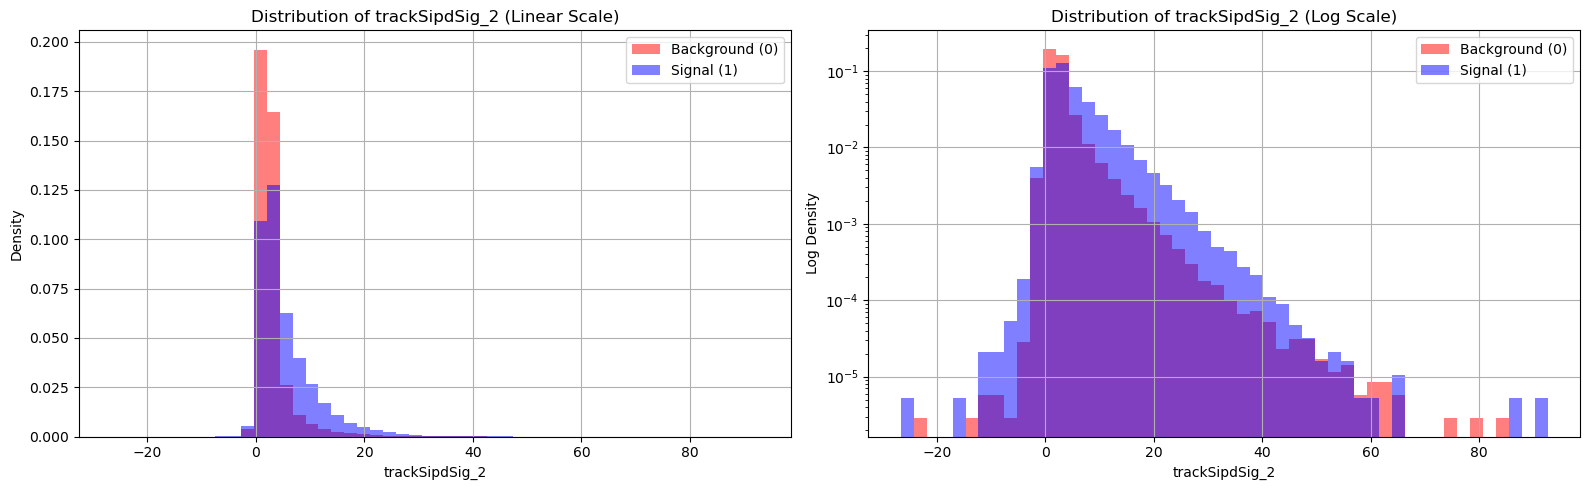

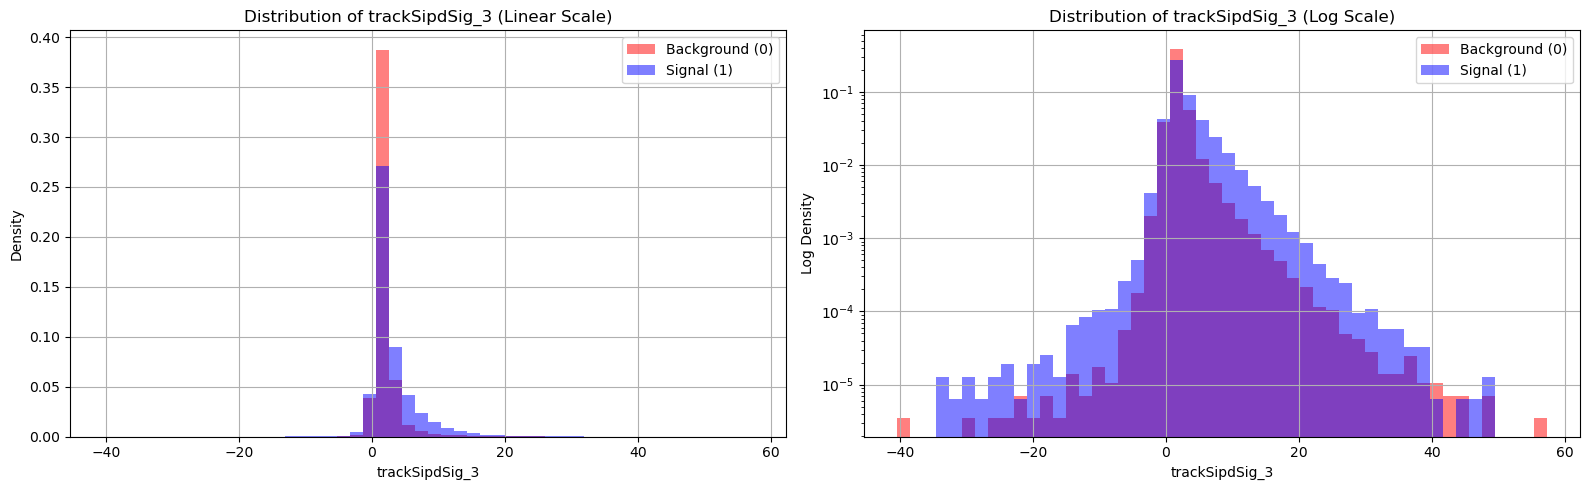

In [7]:
for col in df.columns:
    if col not in ['Unnamed: 0', 'isSignal', 'isBackground']:
        plot_histogram_by_label(df, col, bins=50)


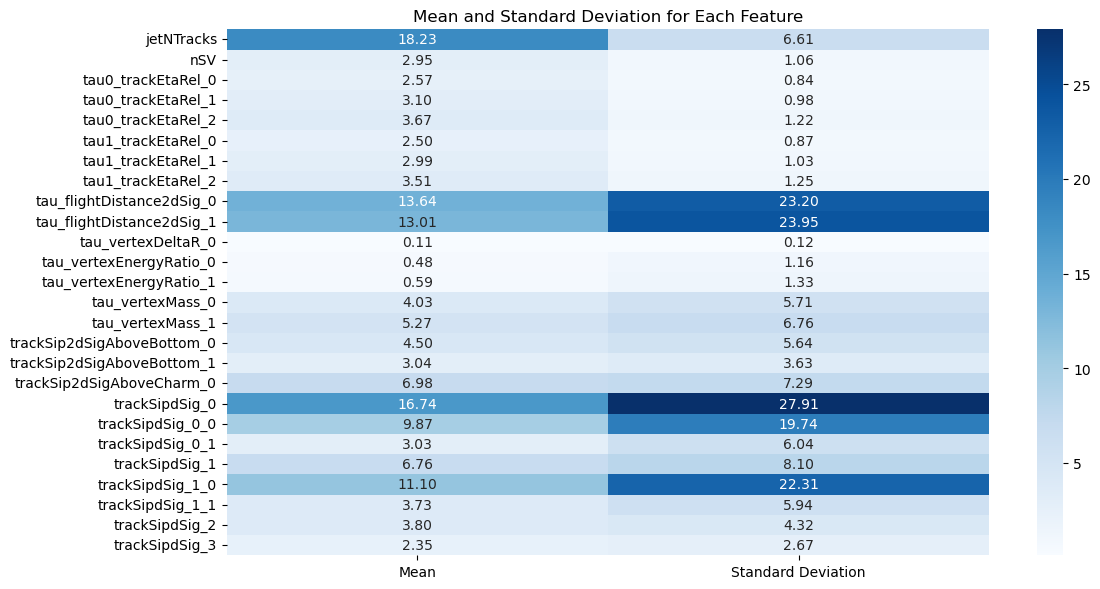

In [8]:
# Remove label columns and index
features_only = df.drop(columns=['Unnamed: 0', 'isSignal', 'isBackground'])

# Calculate mean and std
mean_std_df = features_only.agg(['mean', 'std']).transpose()
mean_std_df.columns = ['Mean', 'Standard Deviation']

# Display as a table
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
import numpy as np

plt.figure(figsize=(12, 6))
sns.heatmap(mean_std_df, annot=True, fmt=".2f", cmap='Blues', cbar=True)
plt.title("Mean and Standard Deviation for Each Feature")
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


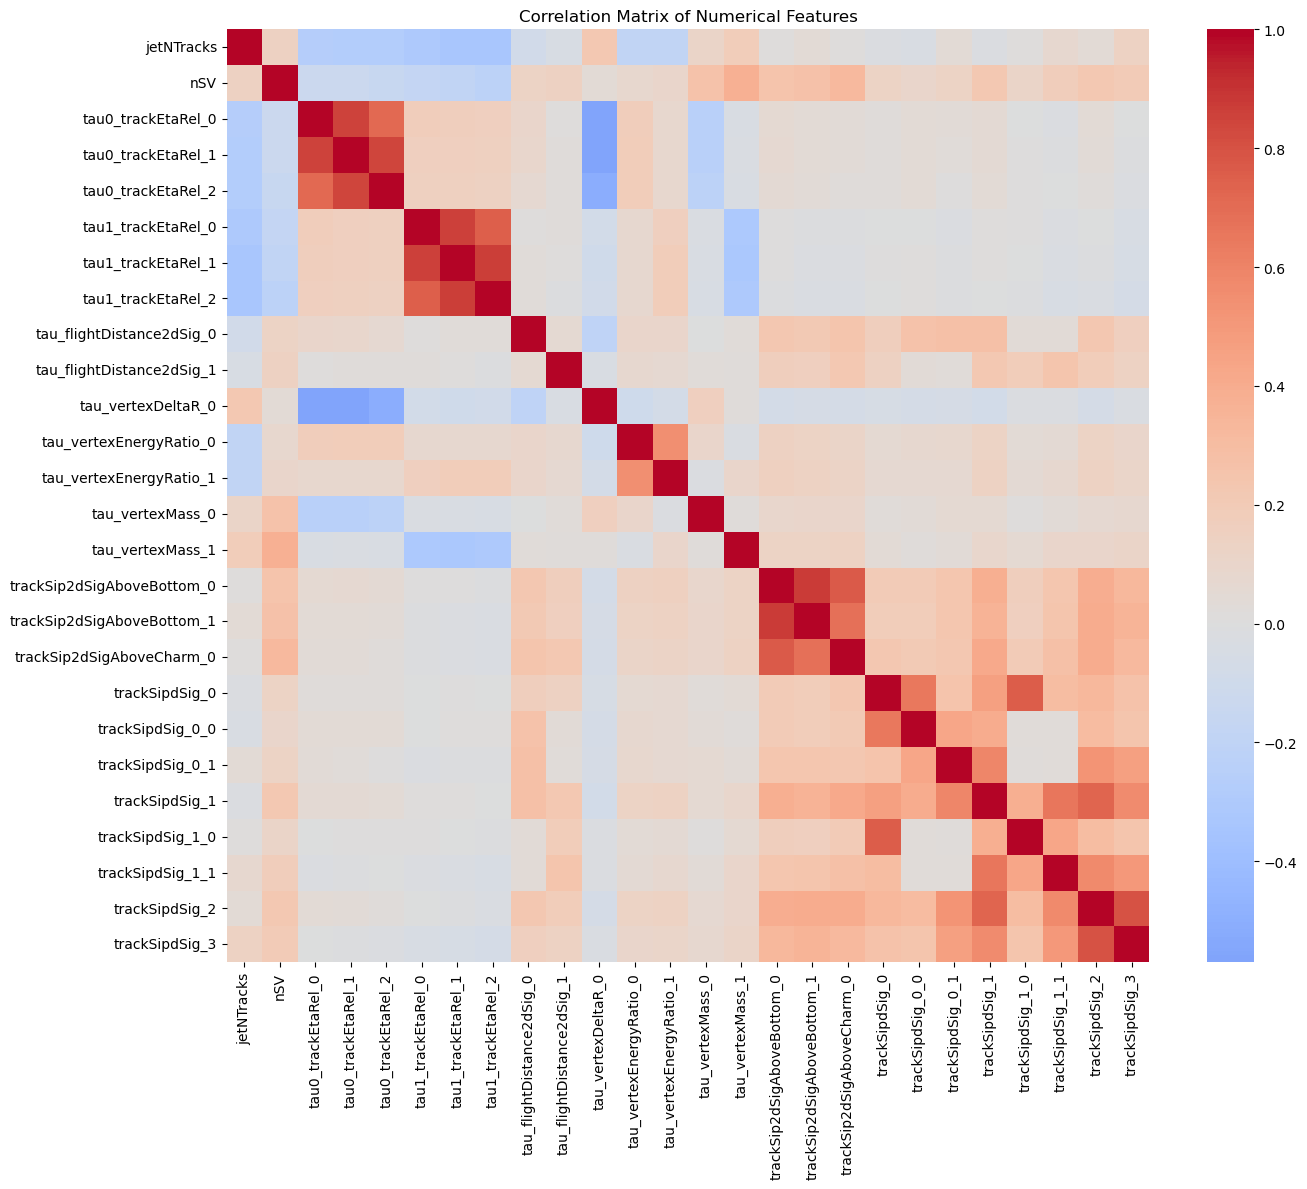

In [9]:
# Drop label and index columns
features_only = df.drop(columns=['Unnamed: 0', 'isSignal', 'isBackground'])

# Calculate correlation matrix
correlation_matrix = features_only.corr()

# Display heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()


In [10]:
# Unstack to get variable pairs
corr_pairs = correlation_matrix.unstack()

# Remove self-correlations
filtered_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]

# Sort and drop duplicates (keep highest correlation for each pair)
sorted_pairs = filtered_pairs.sort_values(ascending=False).drop_duplicates()

# Top 2 positive and negative correlations
top_pos = sorted_pairs.head(2)
top_neg = sorted_pairs.tail(2)

print("Top Positive Correlations:\n", top_pos)
print("Top Negative Correlations:\n", top_neg)


Top Positive Correlations:
 trackSip2dSigAboveBottom_1  trackSip2dSigAboveBottom_0    0.871568
tau1_trackEtaRel_2          tau1_trackEtaRel_1            0.870345
dtype: float64
Top Negative Correlations:
 tau_vertexDeltaR_0  tau0_trackEtaRel_0   -0.559373
                    tau0_trackEtaRel_1   -0.569879
dtype: float64


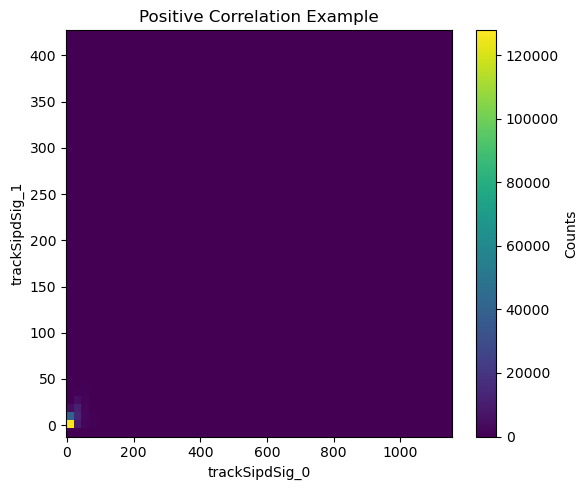

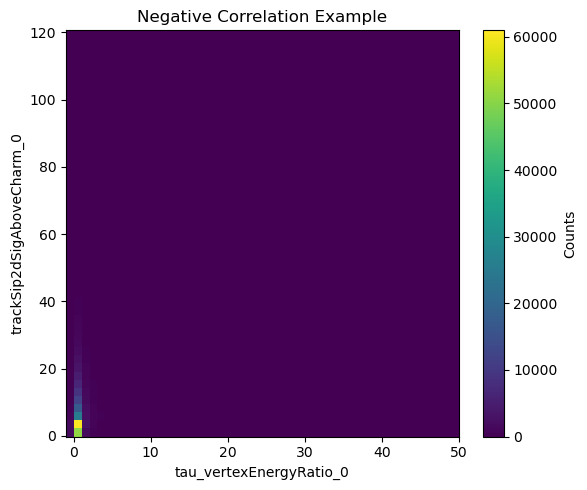

In [11]:
def plot_2d_hist(x, y, title):
    plt.figure(figsize=(6, 5))
    plt.hist2d(df[x], df[y], bins=50, cmap='viridis')
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(title)
    plt.colorbar(label='Counts')
    plt.tight_layout()
    plt.show()

# Example (replace with actual top pair names)
plot_2d_hist('trackSipdSig_0', 'trackSipdSig_1', 'Positive Correlation Example')
plot_2d_hist('tau_vertexEnergyRatio_0', 'trackSip2dSigAboveCharm_0', 'Negative Correlation Example')


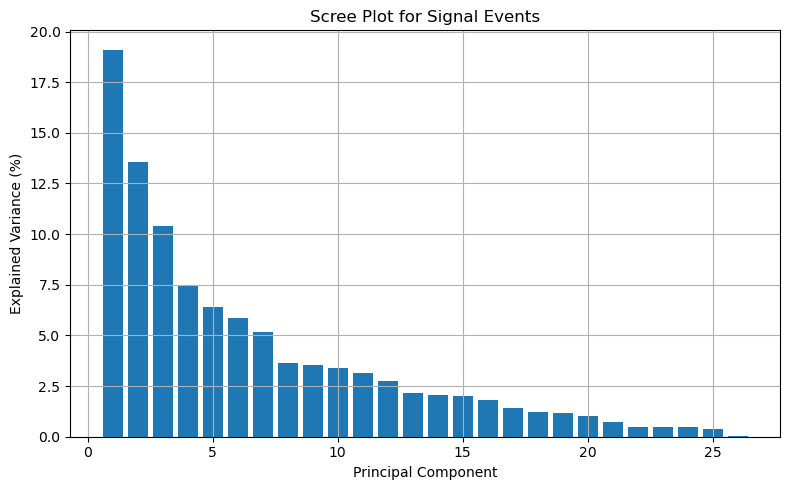

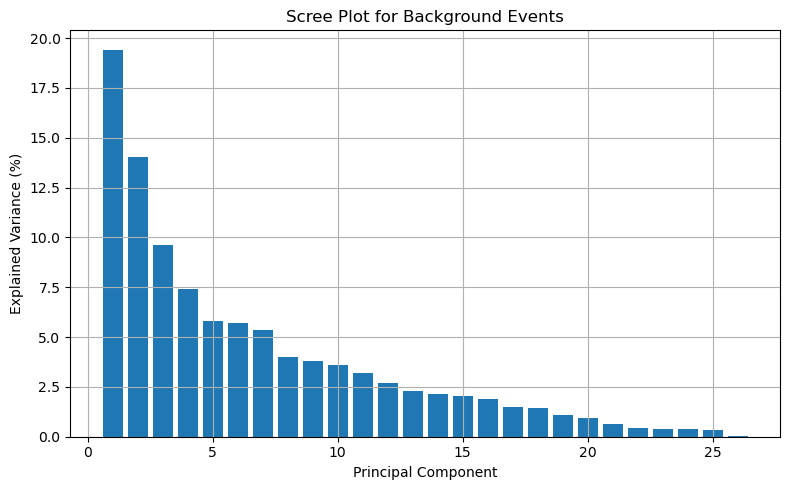

In [12]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

def run_pca_and_plot(data, label_name):
    # 1. Standardize the features
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(data)

    # 2. Apply PCA
    pca = PCA()
    pca_result = pca.fit(scaled_data)

    # 3. Explained variance
    explained_var = pca.explained_variance_ratio_

    # 4. Scree plot
    plt.figure(figsize=(8, 5))
    plt.bar(range(1, len(explained_var) + 1), explained_var * 100)
    plt.xlabel('Principal Component')
    plt.ylabel('Explained Variance (%)')
    plt.title(f'Scree Plot for {label_name} Events')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Filter data
features = df.drop(columns=['Unnamed: 0', 'isSignal', 'isBackground'])

signal_data = features[df['isSignal'] == 1]
background_data = features[df['isSignal'] == 0]

# Run PCA and plot for both
run_pca_and_plot(signal_data, 'Signal')
run_pca_and_plot(background_data, 'Background')


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_pca_weights(pca, feature_names, n_components=3, label_name='Signal'):
    components = pca.components_[:n_components]
    for i, comp in enumerate(components):
        plt.figure(figsize=(10, 4))
        plt.bar(feature_names, comp)
        plt.xticks(rotation=90)
        plt.ylabel("Weight")
        plt.title(f"PCA Component {i+1} Weights ({label_name})")
        plt.tight_layout()
        plt.show()


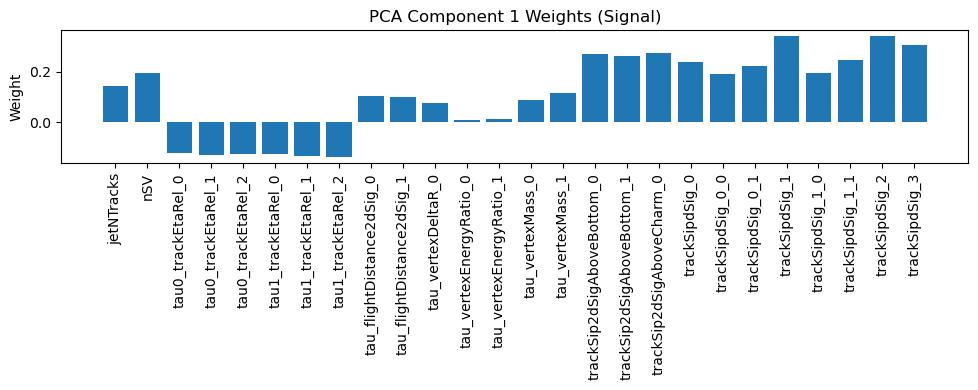

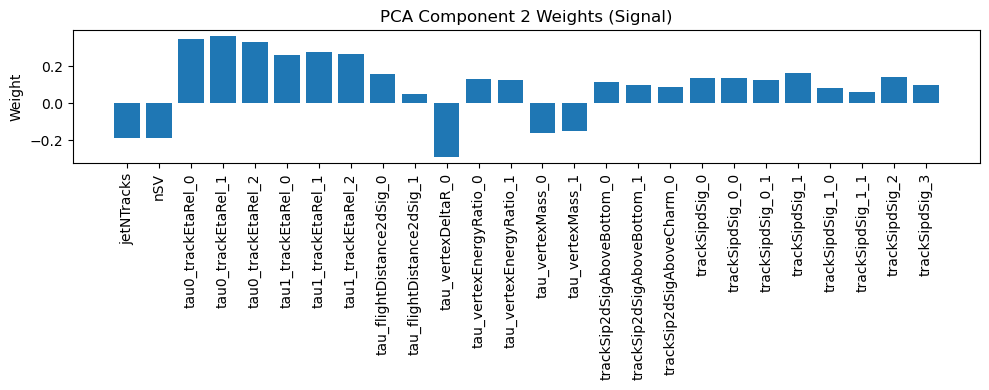

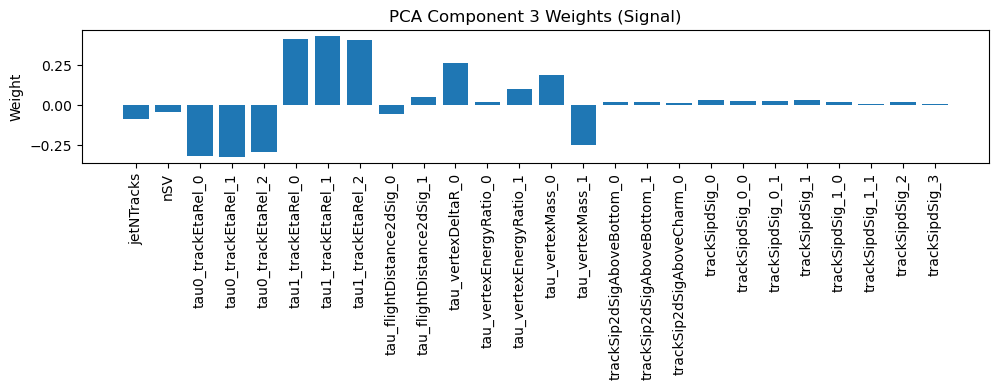

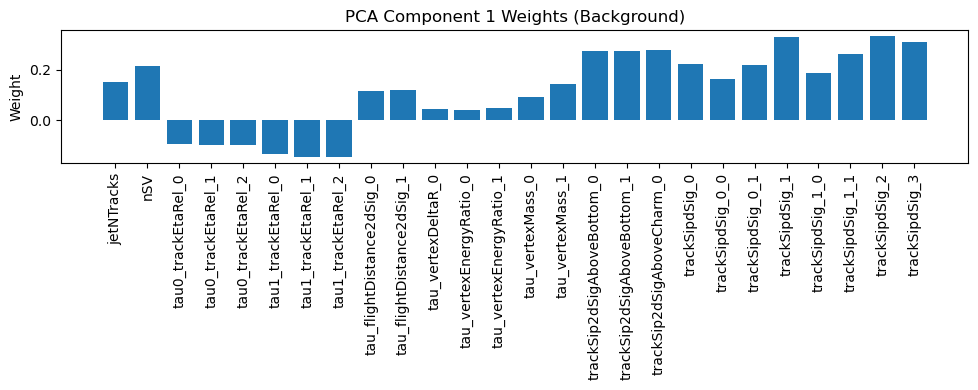

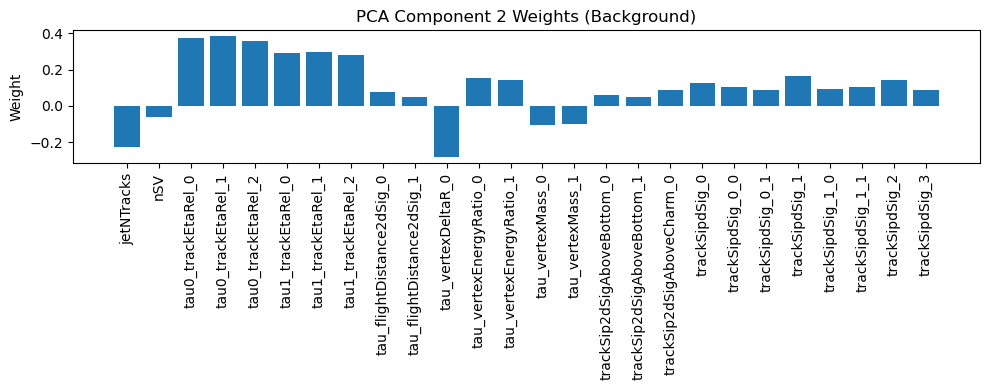

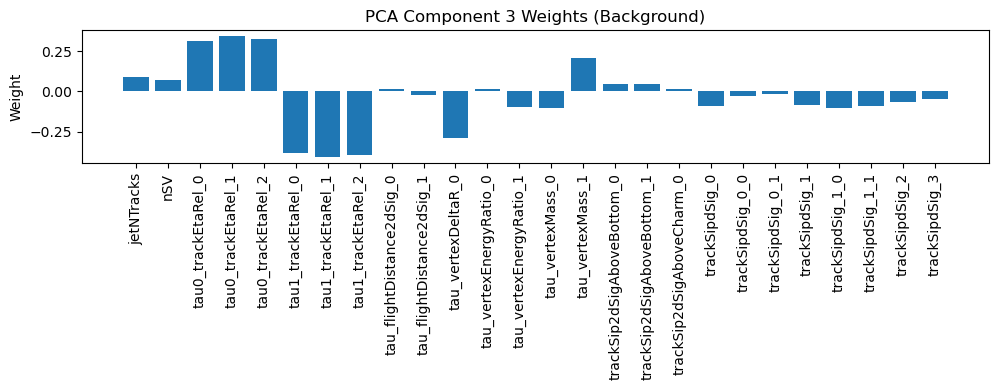

In [14]:
# Redo scaling and PCA
scaler = StandardScaler()
X_signal_scaled = scaler.fit_transform(signal_data)
X_background_scaled = scaler.fit_transform(background_data)

pca_signal = PCA()
pca_signal.fit(X_signal_scaled)

pca_background = PCA()
pca_background.fit(X_background_scaled)

# Plot top 3 components for each
plot_pca_weights(pca_signal, signal_data.columns, n_components=3, label_name='Signal')
plot_pca_weights(pca_background, background_data.columns, n_components=3, label_name='Background')


In [15]:
# Check class distribution
print(df['isSignal'].value_counts(normalize=True))


isSignal
0.0    0.648866
1.0    0.351134
Name: proportion, dtype: float64


In [16]:
from sklearn.utils import resample

# Separate classes
signal = df[df['isSignal'] == 1]
background = df[df['isSignal'] == 0]

# Under-sample background to match signal
background_downsampled = resample(background,
                                   replace=False,
                                   n_samples=len(signal),
                                   random_state=42)

df_balanced = pd.concat([signal, background_downsampled])


In [17]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [18]:
from sklearn.model_selection import train_test_split

# Prepare data
X = df_balanced.drop(columns=['Unnamed: 0', 'isSignal', 'isBackground'])
y = df_balanced['isSignal']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)


In [19]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)


In [20]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)


In [21]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
y_pred_log = logreg.predict(X_test)


In [22]:
from sklearn.metrics import classification_report

print("Naive Bayes:\n", classification_report(y_test, y_pred_gnb))
print("LDA:\n", classification_report(y_test, y_pred_lda))
print("Logistic Regression:\n", classification_report(y_test, y_pred_log))


Naive Bayes:
               precision    recall  f1-score   support

         0.0       0.64      0.89      0.74     23793
         1.0       0.81      0.49      0.61     23793

    accuracy                           0.69     47586
   macro avg       0.72      0.69      0.68     47586
weighted avg       0.72      0.69      0.68     47586

LDA:
               precision    recall  f1-score   support

         0.0       0.75      0.80      0.77     23793
         1.0       0.78      0.73      0.76     23793

    accuracy                           0.76     47586
   macro avg       0.77      0.76      0.76     47586
weighted avg       0.77      0.76      0.76     47586

Logistic Regression:
               precision    recall  f1-score   support

         0.0       0.76      0.82      0.79     23793
         1.0       0.80      0.74      0.77     23793

    accuracy                           0.78     47586
   macro avg       0.78      0.78      0.78     47586
weighted avg       0.78      0.7

In [23]:
from sklearn.decomposition import PCA

# Standardise
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA (keep enough components for ≥85% variance)
pca = PCA(n_components=0.85)
X_pca = pca.fit_transform(X_scaled)

# Train-test split on PCA data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.3, random_state=42, stratify=y)

# Repeat classifiers on PCA-transformed data
logreg_pca = LogisticRegression(max_iter=1000)
logreg_pca.fit(X_train_pca, y_train_pca)
y_pred_log_pca = logreg_pca.predict(X_test_pca)
print("Logistic Regression (PCA):\n", classification_report(y_test_pca, y_pred_log_pca))


Logistic Regression (PCA):
               precision    recall  f1-score   support

         0.0       0.76      0.81      0.78     23793
         1.0       0.80      0.74      0.77     23793

    accuracy                           0.78     47586
   macro avg       0.78      0.78      0.78     47586
weighted avg       0.78      0.78      0.78     47586



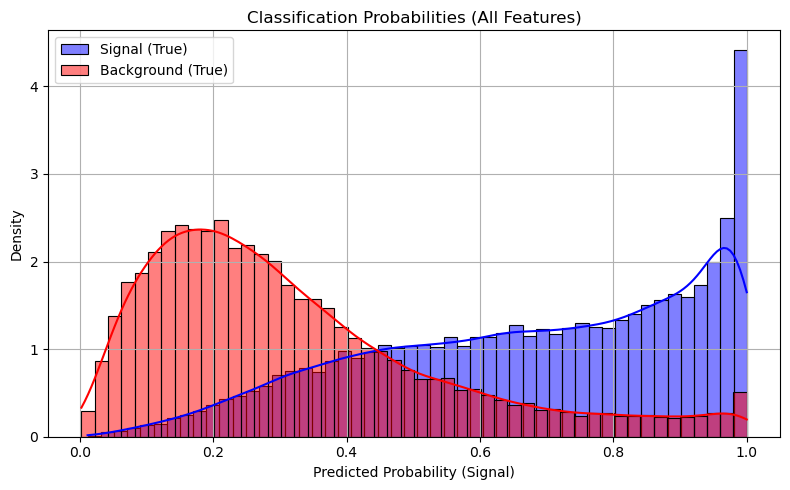

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get predicted probabilities (e.g. from logistic regression)
y_proba = logreg.predict_proba(X_test)[:, 1]  # probability of being signal

# Plot distributions
plt.figure(figsize=(8, 5))
sns.histplot(y_proba[y_test == 1], label='Signal (True)', color='blue', stat='density', bins=50, kde=True)
sns.histplot(y_proba[y_test == 0], label='Background (True)', color='red', stat='density', bins=50, kde=True)
plt.xlabel("Predicted Probability (Signal)")
plt.ylabel("Density")
plt.title("Classification Probabilities (All Features)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


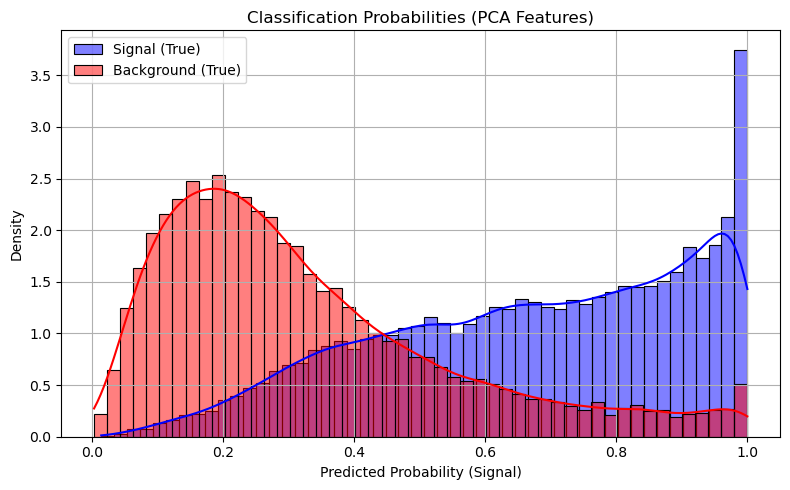

In [25]:
# Get predicted probabilities from PCA-based model
y_proba_pca = logreg_pca.predict_proba(X_test_pca)[:, 1]

plt.figure(figsize=(8, 5))
sns.histplot(y_proba_pca[y_test_pca == 1], label='Signal (True)', color='blue', stat='density', bins=50, kde=True)
sns.histplot(y_proba_pca[y_test_pca == 0], label='Background (True)', color='red', stat='density', bins=50, kde=True)
plt.xlabel("Predicted Probability (Signal)")
plt.ylabel("Density")
plt.title("Classification Probabilities (PCA Features)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [26]:
# Fit a Random Forest on full data
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get importance values
importances = pd.Series(rf.feature_importances_, index=X_train.columns)
important_features = importances.sort_values(ascending=False).head(8).index.tolist()
print("Top selected features:", important_features)


Top selected features: ['tau_vertexEnergyRatio_0', 'trackSip2dSigAboveBottom_0', 'tau_vertexEnergyRatio_1', 'tau_flightDistance2dSig_0', 'trackSipdSig_0', 'trackSipdSig_1', 'jetNTracks', 'trackSip2dSigAboveBottom_1']


In [27]:
# Select only important features
X_subset = df_balanced[important_features]

# Split, scale, and run same classifier as before
X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
    X_subset, y, test_size=0.3, random_state=42, stratify=y)

# Example: Logistic Regression on subset
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_sub, y_train_sub)
y_pred = clf.predict(X_test_sub)

from sklearn.metrics import classification_report
print("Subset Features Performance:\n", classification_report(y_test_sub, y_pred))


Subset Features Performance:
               precision    recall  f1-score   support

         0.0       0.75      0.83      0.79     23793
         1.0       0.81      0.72      0.76     23793

    accuracy                           0.77     47586
   macro avg       0.78      0.77      0.77     47586
weighted avg       0.78      0.77      0.77     47586



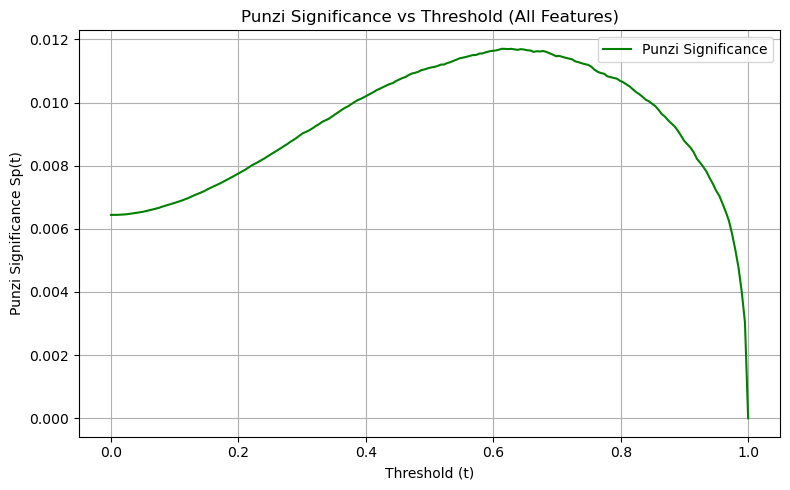

✅ Optimal threshold (All features): 0.613


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Predict probabilities for signal
y_proba = logreg.predict_proba(X_test)[:, 1]

# True labels
y_true = y_test.values

# Create a range of thresholds
thresholds = np.linspace(0, 1, 200)
punzi_scores = []

for t in thresholds:
    # Predicted as signal if proba > t
    predicted_signal = y_proba > t

    # ε(t) = signal efficiency = true signal predicted as signal / total true signal
    epsilon_t = np.sum((predicted_signal == 1) & (y_true == 1)) / np.sum(y_true == 1)

    # B(t) = number of background events predicted as signal
    B_t = np.sum((predicted_signal == 1) & (y_true == 0))

    # Punzi significance
    if B_t == 0:
        punzi = 0  # avoid division by zero
    else:
        punzi = epsilon_t / (1 + np.sqrt(B_t))
    
    punzi_scores.append(punzi)

# Plot the result
plt.figure(figsize=(8, 5))
plt.plot(thresholds, punzi_scores, label='Punzi Significance', color='green')
plt.xlabel("Threshold (t)")
plt.ylabel("Punzi Significance Sp(t)")
plt.title("Punzi Significance vs Threshold (All Features)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Best threshold
best_t = thresholds[np.argmax(punzi_scores)]
print(f"✅ Optimal threshold (All features): {best_t:.3f}")


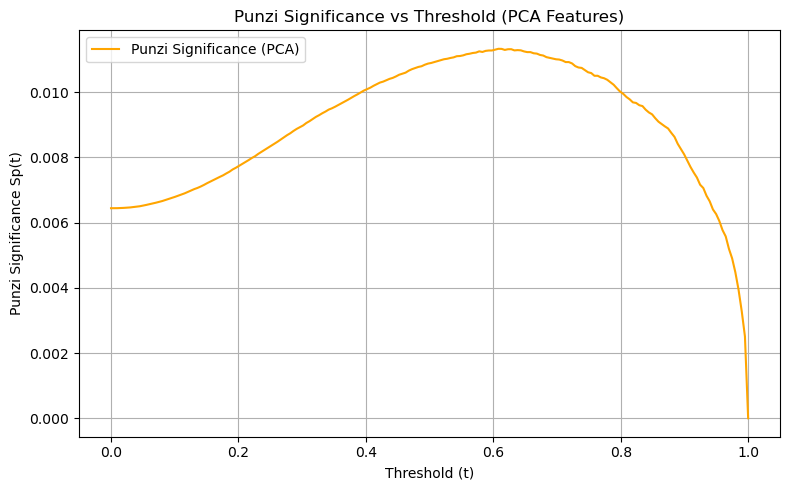

✅ Optimal threshold (PCA features): 0.608


In [29]:
# Predict probabilities for PCA model
y_proba_pca = logreg_pca.predict_proba(X_test_pca)[:, 1]
y_true_pca = y_test_pca.values

# Compute punzi scores for PCA case
punzi_scores_pca = []

for t in thresholds:
    predicted_signal = y_proba_pca > t
    epsilon_t = np.sum((predicted_signal == 1) & (y_true_pca == 1)) / np.sum(y_true_pca == 1)
    B_t = np.sum((predicted_signal == 1) & (y_true_pca == 0))
    punzi = epsilon_t / (1 + np.sqrt(B_t)) if B_t > 0 else 0
    punzi_scores_pca.append(punzi)

# Plot PCA Punzi curve
plt.figure(figsize=(8, 5))
plt.plot(thresholds, punzi_scores_pca, label='Punzi Significance (PCA)', color='orange')
plt.xlabel("Threshold (t)")
plt.ylabel("Punzi Significance Sp(t)")
plt.title("Punzi Significance vs Threshold (PCA Features)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Best threshold
best_t_pca = thresholds[np.argmax(punzi_scores_pca)]
print(f"✅ Optimal threshold (PCA features): {best_t_pca:.3f}")
